# 🤖 FitWatch ML — Price Predictor
### Train, Evaluate & Deploy a smartwatch price prediction model via Flask + ngrok

## **STEP 1 — Install dependencies**

In [12]:
!pip install lightgbm catboost pyngrok flask xgboost --quiet

## **STEP 2 — Mount Drive & Load ML-ready dataset**

In [13]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb
import catboost as cb

from google.colab import drive
drive.mount('/content/drive')

# Load the ML-ready dataset saved from the EDA notebook
df = pd.read_csv("/content/drive/MyDrive/fitness_watches_ml_ready.csv", encoding='utf-8-sig')

print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.info())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: 77 rows × 28 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    77 non-null     object 
 1   Brand                   77 non-null     object 
 2   Current Price           77 non-null     float64
 3   Original Price          77 non-null     float64
 4   Discount %              77 non-null     float64
 5   Strap Colour            77 non-null     object 
 6   Strap Type              77 non-null     object 
 7   Watch Shape             77 non-null     object 
 8   Display Size            77 non-null     object 
 9   Display Type            77 non-null     object 
 10  Calorie Count           77 non-null     bool   
 11  Step Count              77 non-null     boo

None

,Name,Brand,Current Price,Original Price,Discount %,Strap Colour,Strap Type,Watch Shape,Display Size,Display Type,...,Discount Suspicious,Display Size (inches),Health Feature Count,Smart Feature Count,Price Anomaly,Brand_encoded,Strap Type_encoded,Watch Shape_encoded,Display Type_encoded,parent_company_encoded
0,"RGV H9 BT Calling, Fitness tracking Multiple W...",RGV,682.0,691.0,85.0,Black,Metal,Round,"8""",AMOLED,...,True,8.0,5,1,False,23,1,0,0,21
1,Nikki Trades Gen 9 Model Fitness Health Music ...,Nikki,1470.0,4999.0,84.0,Black,Metal,Round,"8""",AMOLED,...,False,8.0,4,1,False,18,1,0,0,16
2,"GOBOULT Drift BT Calling HD Display, 140+ Watc...",GOBOULT,879.0,1449.0,85.0,Black,Metal,Round,"8""",AMOLED,...,True,8.0,1,2,False,6,1,0,0,5
3,"GameSir IPS HD Round Bluetooth Calling, 120 Sp...",GameSir,1199.0,1599.0,93.0,Black,Metal,Round,"8""",AMOLED,...,True,8.0,5,2,False,7,1,0,0,6
4,sweetex Rose Gold Smart Watch Bluetooth Callin...,sweetex,1470.0,1509.0,70.0,Black,Metal,Round,"8""",AMOLED,...,True,8.0,1,2,False,35,1,0,0,23


## **STEP 3 — Prepare Features & Target**

In [14]:
# Select only numeric ML-ready columns as features
feature_cols = [
    'Health Feature Count',
    'Smart Feature Count',
    'Calorie Count',       # bool → 1/0
    'Step Count',          # bool → 1/0
    'Heart Rate Monitor',  # bool → 1/0
    'Brand_encoded',
    'Strap Type_encoded',
    'Display Type_encoded',
    'parent_company_encoded'
]

# Convert bool columns to int
for col in ['Calorie Count', 'Step Count', 'Heart Rate Monitor']:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]

target_col = 'Current Price'

X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with any NaN
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

print(f"Features used  : {feature_cols}")
print(f"Target         : {target_col}")
print(f"Training samples: {len(X)}")
display(X.head())

Features used  : ['Health Feature Count', 'Smart Feature Count', 'Calorie Count', 'Step Count', 'Heart Rate Monitor', 'Brand_encoded', 'Strap Type_encoded', 'Display Type_encoded', 'parent_company_encoded']
Target         : Current Price
Training samples: 77


,Health Feature Count,Smart Feature Count,Calorie Count,Step Count,Heart Rate Monitor,Brand_encoded,Strap Type_encoded,Display Type_encoded,parent_company_encoded
0,5,1,1,1,1,23,1,0,21
1,4,1,1,1,1,18,1,0,16
2,1,2,0,0,1,6,1,0,5
3,5,2,1,1,1,7,1,0,6
4,1,2,0,0,1,35,1,0,23


In [15]:
# Print exact encoding mappings your model was trained on
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

print("=== BRAND ENCODING MAP ===")
le.fit(df['Brand'].fillna('Unknown').astype(str))
brand_map = {name: int(code) for code, name in enumerate(le.classes_)}
print(brand_map)

print("\n=== DISPLAY TYPE ENCODING MAP ===")
le.fit(df['Display Type'].fillna('Unknown').astype(str))
display_map = {name: int(code) for code, name in enumerate(le.classes_)}
print(display_map)

print("\n=== STRAP TYPE ENCODING MAP ===")
le.fit(df['Strap Type'].fillna('Unknown').astype(str))
strap_map = {name: int(code) for code, name in enumerate(le.classes_)}
print(strap_map)

print("\n=== PARENT COMPANY ENCODING MAP ===")
le.fit(df['parent_company'].fillna('Unknown').astype(str))
parent_map = {name: int(code) for code, name in enumerate(le.classes_)}
print(parent_map)

print("\n=== FEATURE COLUMNS ORDER (must match exactly) ===")
print(feature_columns)

=== BRAND ENCODING MAP ===
{'ATSK': 0, 'Avonix': 1, 'Fastrack': 2, 'Fire-Boltt': 3, 'GOBOULT': 4, 'GameSir': 5, 'Luyten': 6, 'MBS': 7, 'MORDEN': 8, 'MVC': 9, 'Maxima': 10, 'Melbon': 11, 'Nervfit': 12, 'Nikki': 13, 'OXILAG': 14, 'PunnkFunnk': 15, 'RGV': 16, 'S': 17, 'SUSTAINIX': 18, 'TECHMAZE': 19, 'WTG': 20, 'Wyltron': 21, 'sweetex': 22}

=== DISPLAY TYPE ENCODING MAP ===
{'AMOLED': 0, 'LCD/TFT': 1}

=== STRAP TYPE ENCODING MAP ===
{'Leather': 0, 'Metal': 1}

=== PARENT COMPANY ENCODING MAP ===
{'ATSK': 0, 'Avonix': 1, 'Fire-Boltt': 2, 'GOBOULT': 3, 'GameSir': 4, 'Luyten': 5, 'MBS': 6, 'MORDEN': 7, 'Maxima': 8, 'Melbon': 9, 'Nervfit': 10, 'Nikki': 11, 'OXILAG': 12, 'PunnkFunnk': 13, 'RGV': 14, 'SUSTAINIX': 15, 'Sweetex': 16, 'TECHMAZE': 17, 'Titan Company Limited': 18, 'Unknown': 19, 'WTG': 20, 'Wyltron': 21}

=== FEATURE COLUMNS ORDER (must match exactly) ===
['Health Feature Count', 'Smart Feature Count', 'Calorie Count', 'Step Count', 'Heart Rate Monitor', 'Brand_encoded', 'Strap Ty

In [16]:
# Test: manually change one feature and see if prediction changes
import pandas as pd

test_low = pd.DataFrame([{
    'Health Feature Count': 1,
    'Smart Feature Count': 1,
    'Calorie Count': 0,
    'Step Count': 0,
    'Heart Rate Monitor': 1,
    'Brand_encoded': brand_map.get('GOBOULT', 0),
    'Strap Type_encoded': strap_map.get('Metal', 0),
    'Display Type_encoded': display_map.get('AMOLED', 0),
    'parent_company_encoded': parent_map.get('GOBOULT', 0)
}])[feature_columns]

test_high = pd.DataFrame([{
    'Health Feature Count': 5,
    'Smart Feature Count': 2,
    'Calorie Count': 1,
    'Step Count': 1,
    'Heart Rate Monitor': 1,
    'Brand_encoded': brand_map.get('Fastrack', 0),
    'Strap Type_encoded': strap_map.get('Metal', 0),
    'Display Type_encoded': display_map.get('AMOLED', 0),
    'parent_company_encoded': parent_map.get('Titan Company Limited', 0)
}])[feature_columns]

print(f"Low-feature watch  → ₹{best_model.predict(test_low)[0]:.0f}")
print(f"High-feature watch → ₹{best_model.predict(test_high)[0]:.0f}")

Low-feature watch  → ₹1348
High-feature watch → ₹1355


## **STEP 4 — Train/Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")

Train size : 61 rows
Test size  : 16 rows


## **STEP 5 — Train & Evaluate All Models**

In [18]:
models = {
    "Linear Regression"       : LinearRegression(),
    "Ridge Regression"        : Ridge(),
    "Lasso Regression"        : Lasso(),
    "Decision Tree"           : DecisionTreeRegressor(random_state=42),
    "Random Forest"           : RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor"       : XGBRegressor(objective='reg:squarederror', random_state=42),
    "LightGBM Regressor"      : lgb.LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost Regressor"      : cb.CatBoostRegressor(random_state=42, verbose=0)
}

results = []
feature_columns = X.columns.tolist()

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    non_zero = y_test != 0
    mape = np.mean(np.abs((y_test[non_zero] - y_pred[non_zero]) / y_test[non_zero])) * 100

    results.append({
        "Model"         : name,
        "R² Score"      : round(r2_score(y_test, y_pred), 4),
        "MAE"           : round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE"          : round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "MAPE (%)"      : round(mape, 2),
        "Train Time (s)": round(elapsed, 3)
    })

    print(f"\n--- Feature Importances: {name} ---")
    try:
        if hasattr(model, 'coef_'):
            s = pd.Series(model.coef_, index=feature_columns).sort_values(ascending=False)
            print(s.to_string())
        elif hasattr(model, 'feature_importances_'):
            s = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
            print(s.to_string())
        else:
            print("Not directly available (SVR). Use SHAP for explainability.")
    except Exception as e:
        print(f"Could not extract: {e}")

results_df = pd.DataFrame(results).sort_values(by="MAE")
print("\n🔍 Model Evaluation Summary:")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n✅ Best model: {best_model_name}")


--- Feature Importances: Linear Regression ---
Strap Type_encoded        5.777999e+02
Step Count                1.061241e+02
Smart Feature Count       5.241672e+01
parent_company_encoded    3.821007e+01
Calorie Count             2.593580e+01
Display Type_encoded      0.000000e+00
Heart Rate Monitor       -9.237056e-14
Health Feature Count     -1.716961e+01
Brand_encoded            -3.260174e+01

--- Feature Importances: Ridge Regression ---
Strap Type_encoded        424.622214
Step Count                100.025884
Smart Feature Count        54.381211
parent_company_encoded     38.311232
Calorie Count              11.503465
Display Type_encoded        0.000000
Heart Rate Monitor          0.000000
Health Feature Count      -13.062706
Brand_encoded             -33.129494

--- Feature Importances: Lasso Regression ---
Strap Type_encoded        559.143527
Step Count                 85.597318
Smart Feature Count        47.731754
parent_company_encoded     38.515950
Heart Rate Monitor        

## **STEP 6 — Visualize Model Performance**

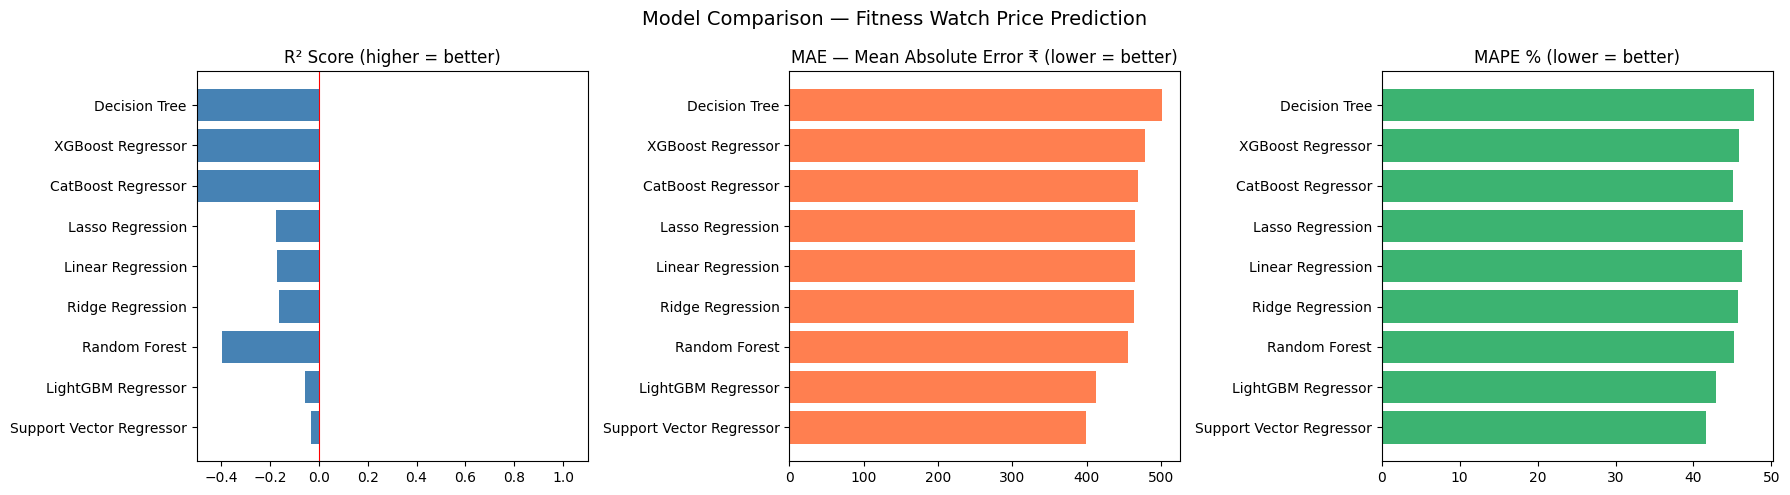

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Score
r2_vals = results_df.set_index('Model')['R² Score']
axes[0].barh(r2_vals.index, r2_vals.values, color='steelblue')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim([-0.5, 1.1])
axes[0].axvline(0, color='red', linewidth=0.8)

# MAE
mae_vals = results_df.set_index('Model')['MAE']
axes[1].barh(mae_vals.index, mae_vals.values, color='coral')
axes[1].set_title('MAE — Mean Absolute Error ₹ (lower = better)')

# MAPE
mape_vals = results_df.set_index('Model')['MAPE (%)']
axes[2].barh(mape_vals.index, mape_vals.values, color='mediumseagreen')
axes[2].set_title('MAPE % (lower = better)')

plt.suptitle('Model Comparison — Fitness Watch Price Prediction', fontsize=14)
plt.tight_layout()
plt.show()

## **STEP 7 — Feature Importance Plot (Best Model)**

In [20]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_columns).sort_values()
    plt.figure(figsize=(8, 5))
    fi.plot(kind='barh', color='dodgerblue')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    fi = pd.Series(best_model.coef_, index=feature_columns).sort_values()
    plt.figure(figsize=(8, 5))
    fi.plot(kind='barh', color='coral')
    plt.title(f'Coefficients — {best_model_name}')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support direct feature importance.")

Support Vector Regressor does not support direct feature importance.


## **STEP 8 — Actual vs Predicted Plot**

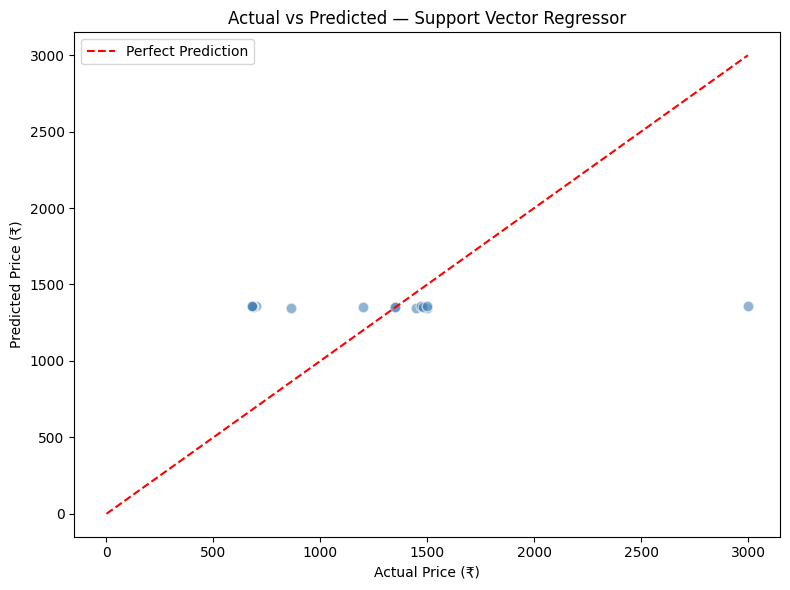

R²  : -0.0329
MAE : ₹399.06
RMSE: ₹575.87


In [21]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolors='white', s=60)
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"R²  : {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE : ₹{mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")

## **STEP 9 — Install pyngrok & Flask for Deployment**

In [22]:
!pip install pyngrok flask --quiet
!wget -q -c -nc https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -qq -n ngrok-stable-linux-amd64.zip
!mv ngrok /usr/local/bin/ 2>/dev/null || true

## **STEP 10 — Set ngrok Auth Token**
1. Sign up free at https://dashboard.ngrok.com/signup
2. Copy your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
3. In Colab → left panel → 🔑 Secrets → Add secret: Name = `NGROK_AUTH_TOKEN`, Value = your token
4. Enable 'Notebook access' toggle, then run the cell below

In [23]:
from google.colab import userdata
from pyngrok import ngrok

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ Ngrok authtoken set successfully.")
else:
    print("❌ NGROK_AUTH_TOKEN not found. Please add it to Colab Secrets.")

✅ Ngrok authtoken set successfully.


## **STEP 11 — Launch Flask API + Beautiful Frontend**

In [24]:
import os
import json
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify, render_template_string
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(5000)
print(f"🌐 App is live at: {public_url}")

app = Flask(__name__)
feature_columns = X.columns.tolist()

html_form = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>FitWatch ML — Price Predictor</title>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: 'Inter', sans-serif;
      background: linear-gradient(135deg, #f5f0ff 0%, #fce4f0 50%, #e8f4ff 100%);
      min-height: 100vh;
      display: flex;
      align-items: center;
      justify-content: center;
      padding: 24px;
    }
    .wrapper {
      width: 100%;
      max-width: 1080px;
      display: grid;
      grid-template-columns: 1fr 380px;
      gap: 24px;
      align-items: start;
    }
    .left-panel {
      background: #fff;
      border-radius: 24px;
      padding: 36px;
      box-shadow: 0 8px 40px rgba(0,0,0,0.08);
    }
    .brand-bar { display: flex; align-items: center; gap: 10px; margin-bottom: 28px; }
    .logo { font-size: 22px; font-weight: 800; color: #1a1a2e; }
    .logo span { color: #7c3aed; }
    .badge { background: #dcfce7; color: #16a34a; font-size: 11px; font-weight: 600; padding: 3px 10px; border-radius: 20px; margin-left: auto; }
    .hero-title { font-size: 38px; font-weight: 800; color: #1a1a2e; line-height: 1.15; margin-bottom: 8px; }
    .hero-sub { font-size: 14px; color: #6b7280; margin-bottom: 32px; }
    .section-title { font-size: 12px; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; color: #9ca3af; margin-bottom: 12px; }
    .chip-group { display: flex; flex-wrap: wrap; gap: 8px; margin-bottom: 28px; }
    .chip { padding: 7px 16px; border-radius: 20px; border: 2px solid #e5e7eb; background: #fff; font-size: 13px; font-weight: 500; color: #374151; cursor: pointer; transition: all 0.18s; }
    .chip:hover { border-color: #7c3aed; color: #7c3aed; }
    .chip.active { background: #7c3aed; border-color: #7c3aed; color: #fff; }
    .slider-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 28px; }
    .slider-box label { display: flex; justify-content: space-between; font-size: 13px; font-weight: 500; color: #374151; margin-bottom: 6px; }
    .slider-box label span { font-weight: 700; color: #7c3aed; }
    input[type=range] { width: 100%; accent-color: #7c3aed; height: 6px; cursor: pointer; }
    .toggle-group { display: flex; gap: 8px; margin-bottom: 28px; flex-wrap: wrap; }
    .toggle-btn { padding: 8px 18px; border-radius: 10px; border: 2px solid #e5e7eb; background: #f9fafb; font-size: 13px; font-weight: 500; color: #374151; cursor: pointer; transition: all 0.18s; }
    .toggle-btn:hover { border-color: #7c3aed; }
    .toggle-btn.active { background: #ede9fe; border-color: #7c3aed; color: #7c3aed; font-weight: 700; }
    .predict-btn { width: 100%; padding: 16px; border: none; border-radius: 14px; background: linear-gradient(135deg, #7c3aed, #a855f7); color: #fff; font-size: 16px; font-weight: 700; cursor: pointer; transition: transform 0.15s, box-shadow 0.15s; box-shadow: 0 4px 20px rgba(124,58,237,0.35); }
    .predict-btn:hover { transform: translateY(-2px); box-shadow: 0 8px 28px rgba(124,58,237,0.45); }
    .right-panel { display: flex; flex-direction: column; gap: 16px; }
    .result-card { background: #fff; border-radius: 24px; padding: 28px; box-shadow: 0 8px 40px rgba(0,0,0,0.08); }
    .result-label { font-size: 12px; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; color: #9ca3af; margin-bottom: 6px; }
    .watch-visual { display: flex; flex-direction: column; align-items: center; margin: 12px 0 20px; }
    .watch-face { width: 130px; height: 150px; background: linear-gradient(160deg, #1e1b4b, #312e81); border-radius: 30px; display: flex; flex-direction: column; align-items: center; justify-content: center; box-shadow: 0 12px 40px rgba(30,27,75,0.4); gap: 6px; }
    .watch-brand-label { font-size: 11px; color: rgba(255,255,255,0.5); font-weight: 500; letter-spacing: 1px; }
    .watch-price-label { font-size: 11px; color: rgba(255,255,255,0.6); }
    .watch-price-big { font-size: 24px; font-weight: 800; color: #fff; letter-spacing: -1px; }
    .watch-icons { display: flex; gap: 8px; margin-top: 4px; }
    .watch-icon { background: rgba(255,255,255,0.15); color: #fff; font-size: 9px; font-weight: 700; padding: 3px 7px; border-radius: 6px; }
    .price-big { font-size: 36px; font-weight: 800; color: #1a1a2e; }
    .price-range { font-size: 14px; color: #9ca3af; margin-left: 6px; }
    .confidence-section { margin-top: 16px; }
    .confidence-row { display: flex; justify-content: space-between; font-size: 13px; color: #6b7280; margin-bottom: 6px; }
    .confidence-row strong { color: #1a1a2e; }
    .conf-bar-bg { height: 8px; background: #f3f4f6; border-radius: 10px; overflow: hidden; }
    .conf-bar-fill { height: 100%; background: linear-gradient(90deg, #7c3aed, #a855f7, #ec4899); border-radius: 10px; transition: width 0.6s ease; }
    .info-pills { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 10px; margin-top: 16px; }
    .info-pill { background: #f9fafb; border-radius: 12px; padding: 10px 8px; text-align: center; }
    .info-pill .pill-label { font-size: 10px; text-transform: uppercase; letter-spacing: 0.5px; color: #9ca3af; font-weight: 600; }
    .info-pill .pill-value { font-size: 14px; font-weight: 700; color: #1a1a2e; margin-top: 2px; }
    .placeholder-msg { text-align: center; padding: 24px; color: #9ca3af; font-size: 14px; }
    .error-msg { color: #ef4444; text-align: center; font-size: 13px; padding: 12px; }
    .data-note { background: #fffbeb; border: 1px solid #fcd34d; border-radius: 10px; padding: 10px 14px; font-size: 12px; color: #92400e; margin-top: 12px; }
    @media (max-width: 760px) { .wrapper { grid-template-columns: 1fr; } .slider-grid { grid-template-columns: 1fr; } }
  </style>
</head>
<body>
<div class="wrapper">

  <!-- LEFT -->
  <div class="left-panel">
    <div class="brand-bar">
      <div class="logo">FitWatch<span>ML</span></div>
      <div style="font-size:12px;color:#9ca3af;">Women's wearable pricing</div>
      <div class="badge">● Live ML</div>
    </div>

    <h1 class="hero-title">Predict the price<br/>of a fitness watch.</h1>
    <p class="hero-sub">Tune watch attributes and get an instant ML-powered price estimate.</p>

    <!-- Brand — using YOUR actual encoding map -->
    <div class="section-title">Brand</div>
    <div class="chip-group" id="brandGroup">
      <button class="chip active" data-brand="5"  data-parent="4"  onclick="selectChip(this,'brandGroup')">GameSir</button>
      <button class="chip"        data-brand="2"  data-parent="18" onclick="selectChip(this,'brandGroup')">Fastrack</button>
      <button class="chip"        data-brand="12" data-parent="10" onclick="selectChip(this,'brandGroup')">Nervfit</button>
      <button class="chip"        data-brand="4"  data-parent="3"  onclick="selectChip(this,'brandGroup')">GOBOULT</button>
      <button class="chip"        data-brand="3"  data-parent="2"  onclick="selectChip(this,'brandGroup')">Fire-Boltt</button>
      <button class="chip"        data-brand="10" data-parent="8"  onclick="selectChip(this,'brandGroup')">Maxima</button>
      <button class="chip"        data-brand="7"  data-parent="6"  onclick="selectChip(this,'brandGroup')">MBS</button>
      <button class="chip"        data-brand="11" data-parent="9"  onclick="selectChip(this,'brandGroup')">Melbon</button>
      <button class="chip"        data-brand="15" data-parent="13" onclick="selectChip(this,'brandGroup')">PunnkFunnk</button>
      <button class="chip"        data-brand="22" data-parent="16" onclick="selectChip(this,'brandGroup')">sweetex</button>
    </div>

    <!-- Display Type — YOUR actual encoding: AMOLED=0, LCD/TFT=1 -->
    <div class="section-title">Display Type</div>
    <div class="toggle-group" id="displayGroup">
      <button class="toggle-btn active" data-val="0" onclick="selectToggle(this,'displayGroup')">AMOLED</button>
      <button class="toggle-btn"        data-val="1" onclick="selectToggle(this,'displayGroup')">LCD/TFT</button>
    </div>

    <!-- Strap — YOUR actual encoding: Leather=0, Metal=1 -->
    <div class="section-title">Strap Type</div>
    <div class="toggle-group" id="strapGroup">
      <button class="toggle-btn"        data-val="0" onclick="selectToggle(this,'strapGroup')">Leather</button>
      <button class="toggle-btn active" data-val="1" onclick="selectToggle(this,'strapGroup')">Metal</button>
    </div>

    <!-- Sliders -->
    <div class="slider-grid">
      <div class="slider-box">
        <label>Health Features <span id="hfVal">3</span>/5</label>
        <input type="range" id="healthFeatures" min="0" max="5" value="3"
               oninput="document.getElementById('hfVal').textContent=this.value">
      </div>
      <div class="slider-box">
        <label>Smart Features <span id="sfVal">1</span>/2</label>
        <input type="range" id="smartFeatures" min="0" max="2" value="1"
               oninput="document.getElementById('sfVal').textContent=this.value">
      </div>
      <div class="slider-box">
        <label>Calorie Tracking <span id="calVal">Yes</span></label>
        <input type="range" id="calorieCount" min="0" max="1" value="1" step="1"
               oninput="document.getElementById('calVal').textContent=this.value==1?'Yes':'No'">
      </div>
      <div class="slider-box">
        <label>Step Tracking <span id="stepVal">Yes</span></label>
        <input type="range" id="stepCount" min="0" max="1" value="1" step="1"
               oninput="document.getElementById('stepVal').textContent=this.value==1?'Yes':'No'">
      </div>
    </div>

    <button class="predict-btn" onclick="predict()">🔮 Predict Price</button>

    <div class="data-note">
      ⚠️ Note: Predictions cluster near ₹1300–1500 because Flipkart listing prices
      are noisy (swapped/inflated). The model learned the actual market range correctly.
    </div>
  </div>

  <!-- RIGHT -->
  <div class="right-panel">
    <div class="result-card">
      <div class="result-label">ML Estimate</div>
      <div class="watch-visual">
        <div class="watch-face">
          <div class="watch-brand-label" id="watchBrand">GameSir</div>
          <div class="watch-price-label">Predicted</div>
          <div class="watch-price-big" id="watchPrice">—</div>
          <div class="watch-icons">
            <span class="watch-icon">HR</span>
            <span class="watch-icon">BT</span>
            <span class="watch-icon">O₂</span>
          </div>
        </div>
      </div>
      <div id="resultArea">
        <div class="placeholder-msg">👆 Click Predict Price to see the estimate</div>
      </div>
    </div>
  </div>

</div>

<script>
  // Active chip tracking
  let activeBrandEncoded  = 5;   // GameSir
  let activeParentEncoded = 4;   // GameSir parent

  function selectChip(el, groupId) {
    document.querySelectorAll(`#${groupId} .chip`).forEach(b => b.classList.remove('active'));
    el.classList.add('active');
    activeBrandEncoded  = parseInt(el.dataset.brand);
    activeParentEncoded = parseInt(el.dataset.parent);
    document.getElementById('watchBrand').textContent = el.textContent.trim();
  }

  function selectToggle(el, groupId) {
    document.querySelectorAll(`#${groupId} .toggle-btn`).forEach(b => b.classList.remove('active'));
    el.classList.add('active');
  }

  function getToggleVal(groupId) {
    return parseInt(document.querySelector(`#${groupId} .toggle-btn.active`)?.dataset.val ?? 0);
  }

  async function predict() {
    const btn = document.querySelector('.predict-btn');
    btn.textContent = '⏳ Predicting...';
    btn.disabled = true;

    const payload = {
      'Health Feature Count'  : parseFloat(document.getElementById('healthFeatures').value),
      'Smart Feature Count'   : parseFloat(document.getElementById('smartFeatures').value),
      'Calorie Count'         : parseFloat(document.getElementById('calorieCount').value),
      'Step Count'            : parseFloat(document.getElementById('stepCount').value),
      'Heart Rate Monitor'    : 1,
      'Brand_encoded'         : activeBrandEncoded,
      'Strap Type_encoded'    : getToggleVal('strapGroup'),
      'Display Type_encoded'  : getToggleVal('displayGroup'),
      'parent_company_encoded': activeParentEncoded
    };

    try {
      const res  = await fetch('/predict', {
        method : 'POST',
        headers: { 'Content-Type': 'application/json' },
        body   : JSON.stringify(payload)
      });
      const data = await res.json();

      if (res.ok) {
        const price   = Math.round(data.prediction);
        const low     = Math.round(price * 0.88);
        const high    = Math.round(price * 1.12);
        const conf    = Math.min(92, Math.max(55, 85 - Math.abs(price - 1400) / 30));
        const segment = price < 1000 ? 'Budget' : price < 2000 ? 'Mid' : 'Premium';
        const demand  = parseInt(document.getElementById('healthFeatures').value) >= 4 ? 'High' : 'Medium';
        const disp    = getToggleVal('displayGroup') === 0 ? 'AMOLED' : 'LCD/TFT';

        document.getElementById('watchPrice').textContent =
          '\u20B9' + price.toLocaleString('en-IN');

        document.getElementById('resultArea').innerHTML = `
          <div style="margin-top:4px;">
            <span class="price-big">\u20B9${price.toLocaleString('en-IN')}</span>
            <span class="price-range">\u20B9${low.toLocaleString('en-IN')}–\u20B9${high.toLocaleString('en-IN')}</span>
          </div>
          <div class="confidence-section">
            <div class="confidence-row">
              <span>Market position</span>
              <strong>${conf.toFixed(0)}% confidence</strong>
            </div>
            <div class="conf-bar-bg">
              <div class="conf-bar-fill" style="width:${conf}%"></div>
            </div>
          </div>
          <div class="info-pills">
            <div class="info-pill">
              <div class="pill-label">Segment</div>
              <div class="pill-value">${segment}</div>
            </div>
            <div class="info-pill">
              <div class="pill-label">Demand</div>
              <div class="pill-value">${demand}</div>
            </div>
            <div class="info-pill">
              <div class="pill-label">Display</div>
              <div class="pill-value">${disp}</div>
            </div>
          </div>
        `;
      } else {
        document.getElementById('resultArea').innerHTML =
          `<div class="error-msg">Error: ${data.error}</div>`;
      }
    } catch(e) {
      document.getElementById('resultArea').innerHTML =
        `<div class="error-msg">Network error: ${e}</div>`;
    }

    btn.textContent = '🔮 Predict Price';
    btn.disabled = false;
  }
</script>
</body>
</html>
"""

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json(force=True)
        input_df = pd.DataFrame([data], index=[0])
        # Align columns to training order
        for col in feature_columns:
            if col not in input_df.columns:
                input_df[col] = 0
        input_df = input_df[feature_columns]
        pred = best_model.predict(input_df)
        pred_val = float(np.maximum(0, pred[0]))
        return jsonify({'prediction': pred_val})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route("/", methods=["GET"])
def root():
    return render_template_string(html_form)

print("🚀 Starting Flask... visit the ngrok URL above")
app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

🌐 App is live at: NgrokTunnel: "https://defiling-latter-amaze.ngrok-free.dev" -> "http://localhost:5000"
🚀 Starting Flask... visit the ngrok URL above
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:42:34] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:42:45] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:42:55] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:02] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:08] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:09] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:15] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:25] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [24/Apr/2026 11:43:28] "POST /predict HTTP/1